# UPI Fraud Detection — Step-by-Step Notebook

This notebook walks through the full pipeline interactively:
1. Generate a synthetic UPI transaction dataset
2. Explore it (EDA)
3. Engineer features
4. Train and compare models
5. Evaluate with the right metrics for imbalanced fraud data
6. Try the model on a custom transaction

> Educational project using **synthetic data** — not a real fraud detection system.

## 1. Setup

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score, roc_auc_score

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed - that's fine, we'll skip it. `pip install xgboost` to include it.")

np.random.seed(42)
random.seed(42)

%matplotlib inline

## 2. Generate Synthetic UPI Transactions

Real UPI data isn't public, so we simulate realistic transaction behavior and
inject known fraud patterns:
- **High-value transfer to a new payee**
- **Odd-hour burst** (multiple transactions at 1-4 AM)
- **Mule account fan-in** (money funneling into a small set of receiver VPAs)
- **Device/SIM takeover** (sudden device change + large amount)

In [8]:
N_USERS = 2000
N_TRANSACTIONS = 50000
FRAUD_RATE = 0.02

BANKS = ["SBI", "HDFC", "ICICI", "Axis", "Kotak", "PNB", "BOB", "Yes Bank"]
TXN_TYPES = ["P2P", "P2M", "BillPay", "Recharge"]

def random_vpa(user_id):
    domains = ["@paytm", "@ybl", "@apl", "@upi", "@oksbi"]
    return f"user{user_id}{random.choice(domains)}"

def generate_users(n_users):
    users = []
    for uid in range(n_users):
        avg_amount = np.random.gamma(shape=2.0, scale=300)
        account_age_days = np.random.randint(10, 2000)
        home_bank = random.choice(BANKS)
        users.append({
            "user_id": uid, "vpa": random_vpa(uid),
            "avg_amount": avg_amount, "account_age_days": account_age_days,
            "bank": home_bank,
        })
    return pd.DataFrame(users)

users = generate_users(N_USERS)
users.head()

,user_id,vpa,avg_amount,account_age_days,bank
0,0,user0@paytm,718.103817,1734,HDFC
1,1,user1@ybl,448.339419,131,Kotak
2,2,user2@ybl,616.045631,1695,Axis
3,3,user3@oksbi,1002.365999,353,HDFC
4,4,user4@oksbi,339.323401,286,HDFC


In [9]:
def generate_transactions(users_df, n_txn, fraud_rate):
    records = []
    start_time = datetime(2025, 1, 1)
    n_fraud_target = int(n_txn * fraud_rate)
    fraud_indices = set(np.random.choice(n_txn, n_fraud_target, replace=False))

    for i in range(n_txn):
        sender = users_df.sample(1).iloc[0]
        is_fraud = i in fraud_indices

        txn_type = random.choice(TXN_TYPES)
        timestamp = start_time + timedelta(minutes=int(np.random.uniform(0, 60*24*180)))
        is_new_payee = np.random.rand() < 0.1

        receiver = users_df.sample(1).iloc[0]
        receiver_vpa = receiver["vpa"]

        amount = max(10, np.random.normal(sender["avg_amount"], sender["avg_amount"] * 0.3))
        hour = timestamp.hour
        txns_last_24h = np.random.poisson(1.5)
        device_change = np.random.rand() < 0.03
        receiver_vpa_age_days = np.random.randint(30, 1500)

        if is_fraud:
            fraud_pattern = random.choice(["high_value_new_payee", "odd_hour_burst", "mule_fanin", "device_takeover"])

            if fraud_pattern == "high_value_new_payee":
                amount = sender["avg_amount"] * np.random.uniform(5, 15)
                is_new_payee = True
                receiver_vpa_age_days = np.random.randint(0, 5)
            elif fraud_pattern == "odd_hour_burst":
                hour = random.choice([1, 2, 3, 4])
                timestamp = timestamp.replace(hour=hour)
                txns_last_24h = np.random.poisson(8) + 5
                amount = sender["avg_amount"] * np.random.uniform(2, 6)
            elif fraud_pattern == "mule_fanin":
                receiver_vpa = f"mule{random.randint(1, 20)}@upi"
                amount = sender["avg_amount"] * np.random.uniform(1, 4)
                receiver_vpa_age_days = np.random.randint(0, 10)
            elif fraud_pattern == "device_takeover":
                device_change = True
                amount = sender["avg_amount"] * np.random.uniform(3, 10)
                is_new_payee = True

        records.append({
            "txn_id": f"TXN{i:07d}", "timestamp": timestamp,
            "sender_vpa": sender["vpa"], "sender_bank": sender["bank"],
            "receiver_vpa": receiver_vpa, "amount": round(amount, 2),
            "txn_type": txn_type, "hour_of_day": hour,
            "is_new_payee": int(is_new_payee), "txns_last_24h": txns_last_24h,
            "device_change": int(device_change),
            "sender_account_age_days": sender["account_age_days"],
            "receiver_vpa_age_days": receiver_vpa_age_days,
            "amount_to_avg_ratio": round(amount / max(sender["avg_amount"], 1), 2),
            "is_fraud": int(is_fraud),
        })
    return pd.DataFrame(records)

df = generate_transactions(users, N_TRANSACTIONS, FRAUD_RATE)
df = df.sort_values("timestamp").reset_index(drop=True)
print(f"Total: {len(df)}  |  Fraud: {df['is_fraud'].sum()} ({df['is_fraud'].mean()*100:.2f}%)")
df.head()

Total: 50000  |  Fraud: 1000 (2.00%)


,txn_id,timestamp,sender_vpa,sender_bank,receiver_vpa,amount,txn_type,hour_of_day,is_new_payee,txns_last_24h,device_change,sender_account_age_days,receiver_vpa_age_days,amount_to_avg_ratio,is_fraud
0,TXN0041975,2025-01-01 00:01:00,user489@oksbi,BOB,user147@oksbi,384.20,P2M,0,0,2,0,1811,1192,0.98,0
1,TXN0010404,2025-01-01 00:03:00,user696@apl,SBI,user759@apl,126.39,P2M,0,0,3,1,58,448,1.24,0
2,TXN0000417,2025-01-01 00:03:00,user1577@paytm,ICICI,user1022@apl,1438.13,Recharge,0,0,2,0,1473,1466,1.16,0
3,TXN0012520,2025-01-01 00:12:00,user1139@oksbi,Axis,user311@oksbi,603.67,BillPay,0,0,1,0,480,783,0.89,0
4,TXN0044119,2025-01-01 00:15:00,user1618@paytm,Yes Bank,user1156@oksbi,218.39,Recharge,0,0,2,0,1529,1480,1.04,0


## 3. Explore the Data (EDA)

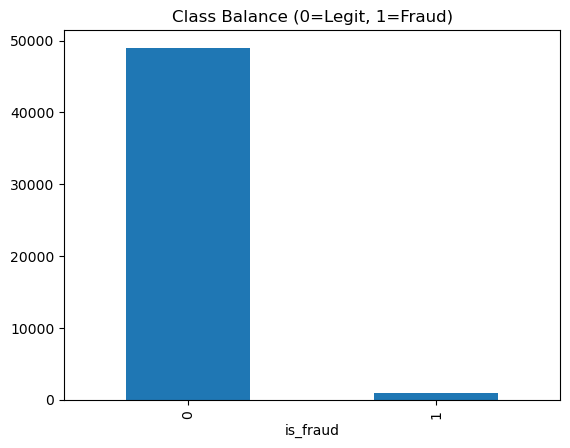

In [11]:
df['is_fraud'].value_counts().plot(kind='bar', title='Class Balance (0=Legit, 1=Fraud)')
plt.show()

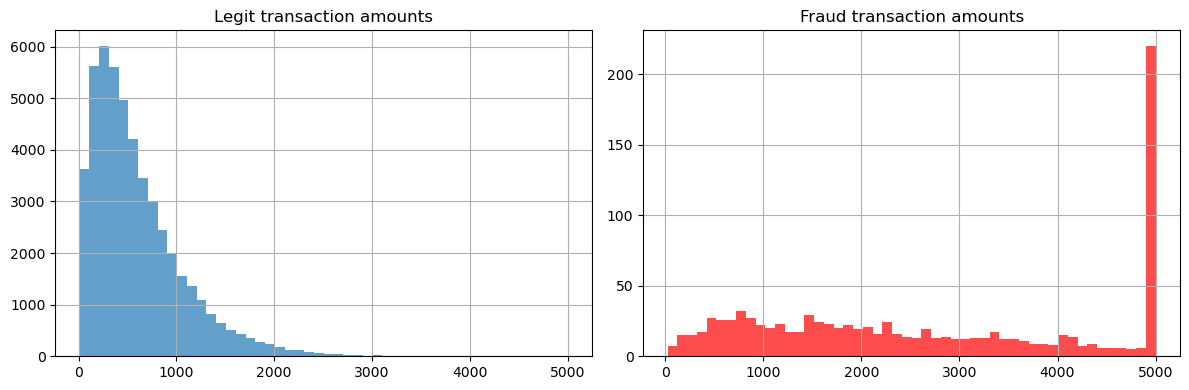

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[df.is_fraud==0]['amount'].clip(upper=5000).hist(bins=50, ax=axes[0], alpha=0.7)
axes[0].set_title('Legit transaction amounts')
df[df.is_fraud==1]['amount'].clip(upper=5000).hist(bins=50, ax=axes[1], alpha=0.7, color='red')
axes[1].set_title('Fraud transaction amounts')
plt.tight_layout()
plt.show()

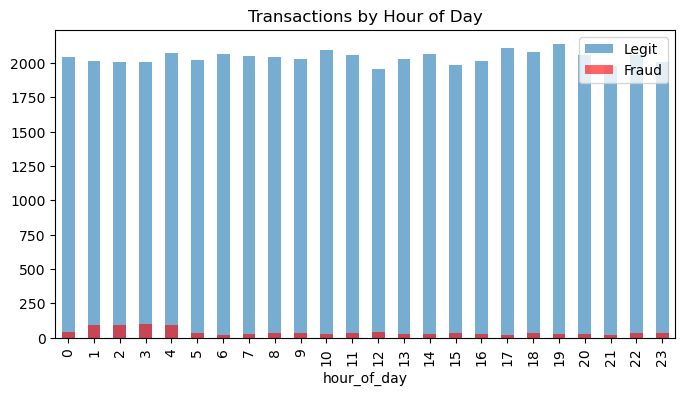

In [13]:
fig, ax = plt.subplots(figsize=(8,4))
df[df.is_fraud==0]['hour_of_day'].value_counts().sort_index().plot(kind='bar', alpha=0.6, label='Legit', ax=ax)
df[df.is_fraud==1]['hour_of_day'].value_counts().sort_index().plot(kind='bar', alpha=0.6, color='red', label='Fraud', ax=ax)
plt.legend()
plt.title('Transactions by Hour of Day')
plt.show()

**Observation:** fraud transactions cluster at odd hours (1-4 AM) and have a fatter
tail on amount — exactly the patterns we injected. In real data these signals exist
but are noisier and overlap more with legitimate behavior.

## 4. Feature Engineering

In [16]:
le_type = LabelEncoder()
le_bank = LabelEncoder()
df["txn_type_enc"] = le_type.fit_transform(df["txn_type"])
df["sender_bank_enc"] = le_bank.fit_transform(df["sender_bank"])

FEATURES = [
    "amount", "hour_of_day", "is_new_payee", "txns_last_24h",
    "device_change", "sender_account_age_days", "receiver_vpa_age_days",
    "amount_to_avg_ratio", "txn_type_enc", "sender_bank_enc",
]

X = df[FEATURES]
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")
print(f"Fraud rate - train: {y_train.mean()*100:.2f}%  test: {y_test.mean()*100:.2f}%")

Train: 37500  Test: 12500
Fraud rate - train: 2.00%  test: 2.00%


## 5. Train and Compare Models

We use **PR-AUC** (precision-recall) as the primary metric — not accuracy.
With ~2% fraud, a model predicting "never fraud" is 98% "accurate" but useless.

In [ ]:
results = []

def evaluate(name, model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"]))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    pr_auc = average_precision_score(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    print(f"PR-AUC: {pr_auc:.4f}  ROC-AUC: {roc_auc:.4f}")
    results.append({"name": name, "model": model, "pr_auc": pr_auc, "y_prob": y_prob})

lr = LogisticRegression(max_iter=2000, class_weight="balanced")
lr.fit(X_train, y_train)
evaluate("Logistic Regression", lr)

In [ ]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
evaluate("Random Forest", rf)

In [ ]:
if HAS_XGB:
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                         scale_pos_weight=scale_pos_weight, eval_metric="aucpr", random_state=42)
    xgb.fit(X_train, y_train)
    evaluate("XGBoost", xgb)
else:
    print("Skipping XGBoost (not installed).")

## 6. Compare Precision-Recall Curves

In [ ]:
plt.figure(figsize=(7,5))
for r in results:
    precision, recall, _ = precision_recall_curve(y_test, r["y_prob"])
    plt.plot(recall, precision, label=f"{r['name']} (AP={r['pr_auc']:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()

best = max(results, key=lambda r: r["pr_auc"])
print(f"Best model: {best['name']} (PR-AUC={best['pr_auc']:.4f})")

## 7. Feature Importance

In [ ]:
best_model = best["model"]
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values()
    importances.plot(kind='barh', figsize=(8,5), title=f'Feature Importance — {best["name"]}')
    plt.tight_layout()
    plt.show()
else:
    print(f"{best['name']} has no feature_importances_ attribute (e.g. Logistic Regression — check .coef_ instead).")

## 8. Try It on a Custom Transaction

In [ ]:
# Simulate one suspicious transaction and score it
custom_txn = pd.DataFrame([{
    "amount": 8000,
    "hour_of_day": 2,
    "is_new_payee": 1,
    "txns_last_24h": 7,
    "device_change": 1,
    "sender_account_age_days": 400,
    "receiver_vpa_age_days": 2,
    "amount_to_avg_ratio": 12.5,
    "txn_type_enc": le_type.transform(["P2P"])[0],
    "sender_bank_enc": le_bank.transform(["HDFC"])[0],
}])[FEATURES]

prob = best_model.predict_proba(custom_txn)[0, 1]
print(f"Fraud probability: {prob*100:.1f}%")
print("Prediction:", "FRAUD" if prob >= 0.5 else "LEGITIMATE")

## 9. Save the Model

So it can be reused in `app.py` (the Streamlit demo) without retraining.

In [ ]:
import joblib
import os
os.makedirs("models", exist_ok=True)
joblib.dump({"model": best_model, "features": FEATURES}, "models/fraud_model.pkl")
df.to_csv("data/upi_transactions.csv", index=False)
print("Saved model to models/fraud_model.pkl and dataset to data/upi_transactions.csv")

## Next steps / extensions

- Make fraud patterns noisier/more realistic (less cleanly separable)
- Add a hand-written rules engine and compare it against the ML model
- Try graph-based mule detection with `networkx` (fan-in patterns)
- Try unsupervised anomaly detection (`IsolationForest`) assuming no labels exist
- Add SHAP explainability for individual predictions
- Run `streamlit run app.py` for the interactive demo version of this model